In [16]:
import os
import sys
import json
import numpy as np
import torch
import pandas as pd
import matplotlib.pyplot as plt

# estilo opcional
import matplotx
plt.style.use(matplotx.styles.dracula)

# =========================================================
# Paths
# =========================================================
BASE = "/home/kingsman/Escritorio/PhD/PINN_paper"

ORBIT_CODEDIR = os.path.join(BASE, "best_orbinet", "orbit_emulator")
if ORBIT_CODEDIR not in sys.path:
    sys.path.insert(0, ORBIT_CODEDIR)

from orbit_emulator import (
    load_model_from_ckpt,
    bcrit,
    u_phi_general,
    predict_u,
)

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print("DEVICE:", DEVICE)

DEVICE: cuda


In [17]:
# =========================================================
# OrbitNet
# =========================================================
ORBIT_CKPT = "/home/kingsman/Escritorio/PhD/PINN_paper/best_orbinet/ckpt/best_re27_seed150.pt"

orbit_model, orbit_ckpt = load_model_from_ckpt(ORBIT_CKPT, map_location=DEVICE)
orbit_model = orbit_model.to(DEVICE)
orbit_model.eval()

orbit_cfg = orbit_ckpt.get("config", {})
K = int(orbit_cfg.get("K", 8))
ADD_VALID_FLAG = bool(int(orbit_cfg.get("add_valid_flag", 1)))
TARGET_TF = str(orbit_cfg.get("target_transform", "log1p"))

print("OrbitNet loaded")
print("K =", K)
print("ADD_VALID_FLAG =", ADD_VALID_FLAG)
print("TARGET_TF =", TARGET_TF)

OrbitNet loaded
K = 8
ADD_VALID_FLAG = True
TARGET_TF = log1p


In [18]:
# =========================================================
# DeflectionNet
# =========================================================
DEFLECT_BASE = "/home/kingsman/Escritorio/PhD/PINN_paper/test_run"
DEFLECT_CKPT = os.path.join(DEFLECT_BASE, "ckpt", "best.pt")
NORM_JSON = os.path.join(DEFLECT_BASE, "tables", "normalization.json")

In [19]:
class MLPDeflectionNet(torch.nn.Module):
    def __init__(self, in_dim, width=256, depth=4, dropout=0.05):
        super().__init__()
        layers = []
        d = in_dim
        for _ in range(depth):
            layers += [
                torch.nn.Linear(d, width),
                torch.nn.GELU(),
                torch.nn.Dropout(dropout),
            ]
            d = width
        layers += [torch.nn.Linear(d, 1)]
        self.net = torch.nn.Sequential(*layers)

    def forward(self, x):
        return self.net(x)

def load_deflection_model(ckpt_path, map_location="cpu"):
    ckpt = torch.load(ckpt_path, map_location=map_location)
    cfg = ckpt["config"]

    model = MLPDeflectionNet(
        in_dim=len(ckpt["features"]),
        width=cfg["width"],
        depth=cfg["depth"],
        dropout=cfg["dropout"],
    )
    model.load_state_dict(ckpt["model_state"])
    model.eval()
    return model, ckpt

deflection_model, deflection_ckpt = load_deflection_model(DEFLECT_CKPT, map_location=DEVICE)
deflection_model = deflection_model.to(DEVICE)

with open(NORM_JSON, "r") as f:
    norm_info = json.load(f)

print("DeflectionNet loaded")
print("features:", norm_info["features"])

DeflectionNet loaded
features: ['Rs', 'b', 'b_over_bc', 'Rs_over_b', 'log_gap']


In [20]:
def cubic_roots_u(Rs, b):
    coeff = [1.0, -1.0, 0.0, (Rs / b) ** 2]
    roots = np.roots(coeff)
    roots = np.real_if_close(roots, tol=1e5)
    if np.any(np.abs(np.imag(roots)) > 1e-10):
        return None
    return np.sort(np.real(roots))

def deflection_exact_eq56(Rs, b):
    from scipy.special import ellipk, ellipkinc

    roots = cubic_roots_u(Rs, b)
    if roots is None:
        return np.nan, {}

    u1, u2, u3 = roots
    if not (u1 < 0 < u2 < u3 < 1):
        return np.nan, {"u1": u1, "u2": u2, "u3": u3}

    m = (u2 - u1) / (u3 - u1)
    if not (0 <= m < 1):
        return np.nan, {"u1": u1, "u2": u2, "u3": u3, "m": m}

    z = np.sqrt((-u1) / (u2 - u1))
    z = np.clip(z, 0.0, 1.0)

    Kc = ellipk(m)
    Fi = ellipkinc(np.arcsin(z), m)
    Delta_phi = 4.0 / np.sqrt(u3 - u1) * (Kc - Fi)
    delta_phi = Delta_phi - np.pi
    return float(delta_phi), {"Delta_phi": float(Delta_phi)}

def orbit_xy(phi, u, Rs=1.0):
    phi = np.asarray(phi, float)
    u = np.asarray(u, float)
    r = np.where(np.isfinite(u) & (u > 0), Rs / u, np.nan)
    x = r * np.cos(phi)
    y = r * np.sin(phi)
    return x, y, r

@torch.no_grad()
def predict_deflection(model, norm_info, Rs, b, device="cpu"):
    Rs = np.atleast_1d(Rs).astype(np.float32)
    b = np.atleast_1d(b).astype(np.float32)

    if len(Rs) == 1 and len(b) > 1:
        Rs = np.full_like(b, Rs.item(), dtype=np.float32)
    elif len(b) == 1 and len(Rs) > 1:
        b = np.full_like(Rs, b.item(), dtype=np.float32)
    elif len(Rs) != len(b):
        raise ValueError(f"Rs and b must have same length, got {len(Rs)} vs {len(b)}")

    bc = bcrit(Rs)

    feat_df = pd.DataFrame({
        "Rs": Rs,
        "b": b,
        "b_over_bc": b / bc,
        "Rs_over_b": Rs / b,
        "log_gap": np.log((b / bc) - 1.0),
    })

    features = norm_info["features"]
    X = feat_df[features].values.astype(np.float32)

    mu_x = np.asarray(norm_info["mu_x"], dtype=np.float32)
    std_x = np.asarray(norm_info["std_x"], dtype=np.float32)
    mu_y = float(norm_info["mu_y"])
    std_y = float(norm_info["std_y"])

    Xn = (X - mu_x) / std_x
    Xn = torch.from_numpy(Xn).to(device)

    model.eval()
    z = model(Xn).cpu().numpy().squeeze()
    y = np.expm1(z * std_y + mu_y)
    return np.atleast_1d(y)

In [260]:
Rs = 1.0
bc = bcrit(Rs)

phi = np.linspace(1e-4, 9.5, 3000).astype(np.float32)

u0 = 0.15
b = 1.0068 * bc

out = evaluate_joint_system(phi, u0=u0, b=b, Rs=Rs)

print("Rs =", Rs)
print("b/bc =", b / bc)
print("dphi_exact =", out["dphi_exact"])
print("dphi_pred  =", out["dphi_pred"])
print("abs err    =", abs(out["dphi_pred"] - out["dphi_exact"]))

Rs = 1.0
b/bc = 1.0068
dphi_exact = 4.608159205147398
dphi_pred  = 4.607579393548337
abs err    = 0.0005798115990609531


In [261]:
def evaluate_joint_system(phi, u0, b, Rs=1.0):
    # órbita emulada
    u_hat = predict_u(
        orbit_model,
        phi,
        u0,
        b,
        Rs=Rs,
        K=K,
        add_valid_flag=ADD_VALID_FLAG,
        target_transform=TARGET_TF,
    )

    # órbita exacta
    u_true, _ = u_phi_general(phi, Rs=Rs, b=b, u0=u0, phi0=0.0, branch=None, region="scatter")

    # dphi exacto y NN
    bc = bcrit(Rs)
    dphi_exact = np.nan
    dphi_pred = np.nan

    if b > bc:
        dphi_exact, _ = deflection_exact_eq56(Rs, b)
        dphi_pred = predict_deflection(deflection_model, norm_info, Rs, b, device=DEVICE)[0]

    return {
        "u_true": u_true,
        "u_hat": u_hat,
        "dphi_exact": dphi_exact,
        "dphi_pred": dphi_pred,
    }

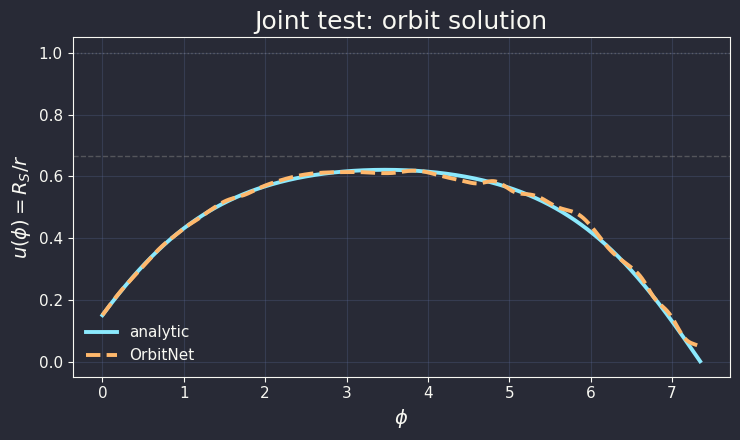

In [262]:
u_true = out["u_true"]
u_hat = out["u_hat"]

m = np.isfinite(u_true) & (u_true > 0) & np.isfinite(u_hat) & (u_hat > 0)

plt.figure(figsize=(7.5, 4.5))
plt.plot(phi[m], u_true[m], label="analytic")
plt.plot(phi[m], u_hat[m], "--", label="OrbitNet")
plt.axhline(2/3, ls="--", lw=1, c="gray", alpha=0.5)
plt.axhline(1.0, ls=":", lw=1, c="gray", alpha=0.5)
plt.xlabel(r"$\phi$")
plt.ylabel(r"$u(\phi)=R_S/r$")
plt.title("Joint test: orbit solution")
plt.grid(True, alpha=0.25)
plt.legend()
plt.tight_layout()
plt.show()

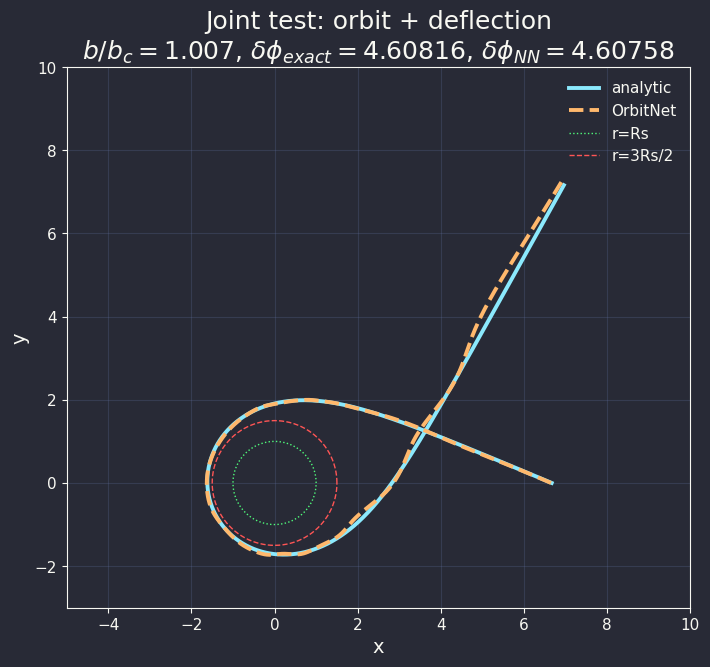

In [263]:
xT, yT, rT = orbit_xy(phi[m], u_true[m], Rs=Rs)
xP, yP, rP = orbit_xy(phi[m], u_hat[m], Rs=Rs)

rmax_plot = 10.0
mT = np.isfinite(rT) & (rT < rmax_plot)
mP = np.isfinite(rP) & (rP < rmax_plot)

fig, ax = plt.subplots(figsize=(7.2, 7.2))
ax.plot(xT[mT], yT[mT], label="analytic")
ax.plot(xP[mP], yP[mP], "--", label="OrbitNet")

th = np.linspace(0, 2*np.pi, 600)
ax.plot(Rs*np.cos(th), Rs*np.sin(th), ":", lw=1, label="r=Rs")
ax.plot(1.5*Rs*np.cos(th), 1.5*Rs*np.sin(th), "--", lw=1, label="r=3Rs/2")

ax.set_xlim(-rmax_plot, rmax_plot)
ax.set_ylim(-rmax_plot, rmax_plot)
ax.set_aspect("equal", adjustable="box")
ax.set_xlabel("x")
ax.set_ylabel("y")
ax.set_ylim(-3.0, rmax_plot)
ax.set_xlim(-5.0, rmax_plot)
ax.set_title(
    "Joint test: orbit + deflection\n"
    + rf"$b/b_c={b/bc:.3f}$, "
    + rf"$\delta\phi_{{exact}}={out['dphi_exact']:.5f}$, "
    + rf"$\delta\phi_{{NN}}={out['dphi_pred']:.5f}$"
)
ax.grid(True, alpha=0.25)
ax.legend()
plt.tight_layout()
plt.show()

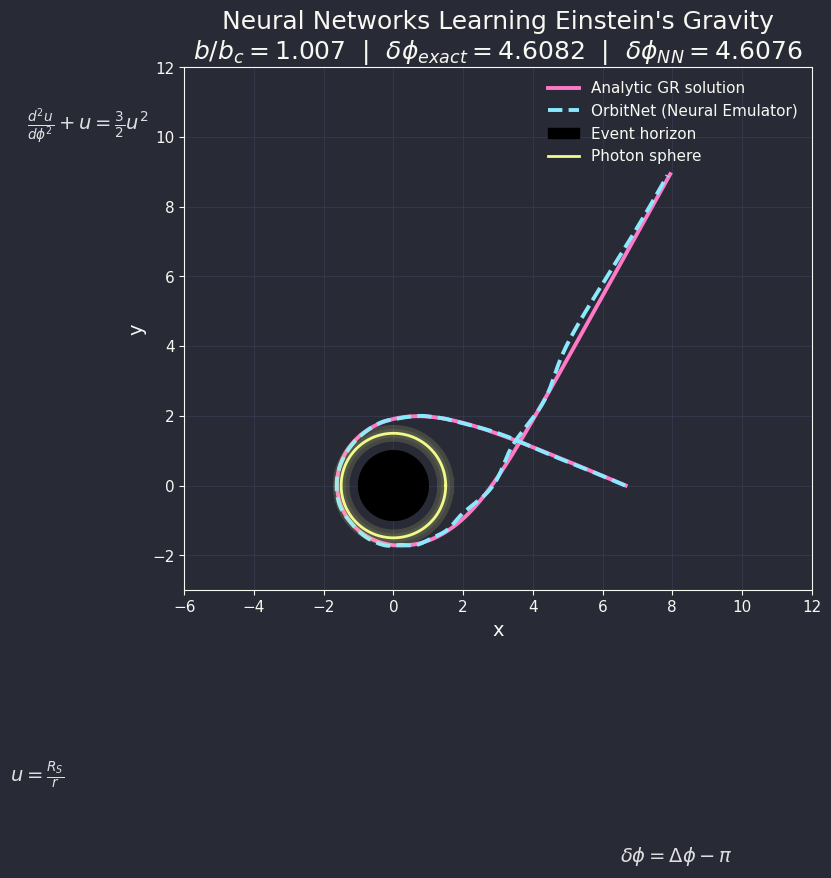

In [264]:
import numpy as np
import matplotlib.pyplot as plt
import matplotx

plt.style.use(matplotx.styles.dracula)

# =============================
# estética colores
# =============================
C_ANALYTIC = "#ff79c6"
C_MODEL    = "#8be9fd"
C_HORIZON  = "#000000"
C_PHOTON   = "#f1fa8c"
C_TEXT     = "white"

plt.rcParams.update({
    "axes.labelsize": 14,
    "axes.titlesize": 18,
    "xtick.labelsize": 11,
    "ytick.labelsize": 11,
    "legend.fontsize": 11,
    "lines.linewidth": 2.8,
})

# =============================
# órbita
# =============================
xT, yT, rT = orbit_xy(phi[m], u_true[m], Rs=Rs)
xP, yP, rP = orbit_xy(phi[m], u_hat[m], Rs=Rs)

rmax_plot = 12
mT = np.isfinite(rT) & (rT < rmax_plot)
mP = np.isfinite(rP) & (rP < rmax_plot)

fig, ax = plt.subplots(figsize=(8.5, 8.5))

ax.plot(xT[mT], yT[mT], color=C_ANALYTIC, label="Analytic GR solution")
ax.plot(xP[mP], yP[mP], "--", color=C_MODEL, label="OrbitNet (Neural Emulator)")

# =============================
# Black hole (filled)
# =============================
th = np.linspace(0, 2*np.pi, 1000)

ax.fill(
    Rs*np.cos(th),
    Rs*np.sin(th),
    color="black",
    zorder=10,
    label="Event horizon"
)

# photon sphere glow
for alpha in [0.15, 0.08, 0.04]:
    ax.plot(
        1.5*Rs*np.cos(th),
        1.5*Rs*np.sin(th),
        color=C_PHOTON,
        lw=8*alpha*10,
        alpha=alpha
    )

ax.plot(
    1.5*Rs*np.cos(th),
    1.5*Rs*np.sin(th),
    color=C_PHOTON,
    lw=2,
    label="Photon sphere"
)

# =============================
# Matemáticas decorativas
# =============================
ax.text(
    -10.5, 10.2,
    r"$\frac{d^2u}{d\phi^2}+u=\frac{3}{2}u^2$",
    fontsize=14,
    color=C_TEXT,
    alpha=0.85
)

ax.text(
    6.5, -10.8,
    r"$\delta\phi=\Delta\phi-\pi$",
    fontsize=14,
    color=C_TEXT,
    alpha=0.85
)

ax.text(
    -11, -8.5,
    r"$u=\frac{R_S}{r}$",
    fontsize=14,
    color=C_TEXT,
    alpha=0.85
)

# =============================
# framing cinematográfico
# =============================
ax.set_xlim(-6, rmax_plot)
ax.set_ylim(-3, rmax_plot)

ax.set_aspect("equal")

ax.set_xlabel("x")
ax.set_ylabel("y")

ax.set_title(
    "Neural Networks Learning Einstein's Gravity\n"
    + rf"$b/b_c={b/bc:.3f}$  |  "
    + rf"$\delta\phi_{{exact}}={out['dphi_exact']:.4f}$  |  "
    + rf"$\delta\phi_{{NN}}={out['dphi_pred']:.4f}$"
)

ax.grid(True, alpha=0.18)
ax.legend(frameon=False)

plt.tight_layout()
plt.show()

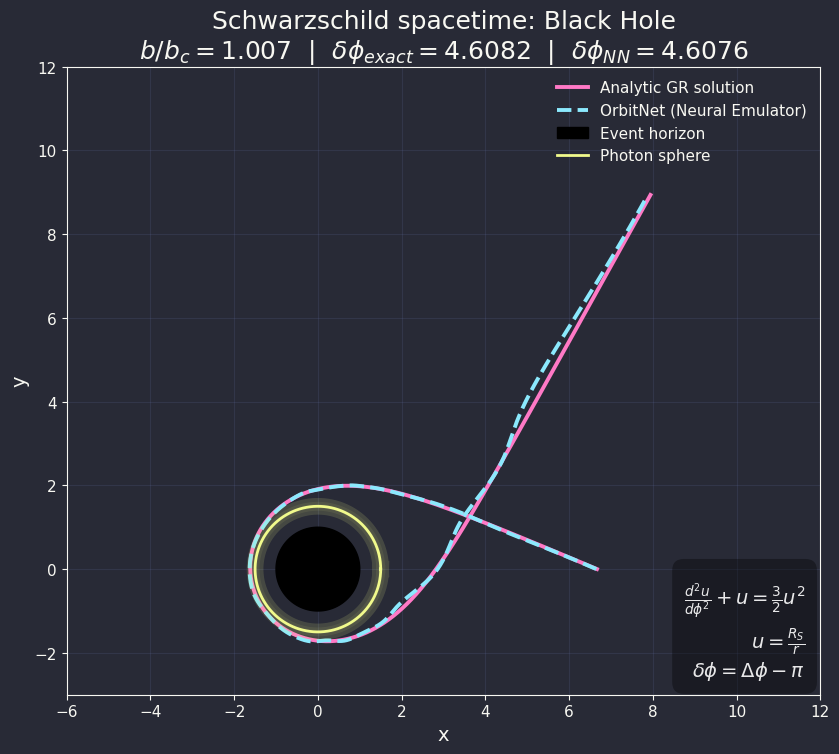

In [265]:
# import numpy as np
# import matplotlib.pyplot as plt
# import matplotx

# plt.style.use(matplotx.styles.dracula)

# =============================
# estética colores
# =============================
C_ANALYTIC = "#ff79c6"
C_MODEL    = "#8be9fd"
C_HORIZON  = "#000000"
C_PHOTON   = "#f1fa8c"
C_TEXT     = "white"

plt.rcParams.update({
    "axes.labelsize": 14,
    "axes.titlesize": 18,
    "xtick.labelsize": 11,
    "ytick.labelsize": 11,
    "legend.fontsize": 11,
    "lines.linewidth": 2.8,
})

# =============================
# órbita
# =============================
xT, yT, rT = orbit_xy(phi[m], u_true[m], Rs=Rs)
xP, yP, rP = orbit_xy(phi[m], u_hat[m], Rs=Rs)

rmax_plot = 12
mT = np.isfinite(rT) & (rT < rmax_plot)
mP = np.isfinite(rP) & (rP < rmax_plot)

fig, ax = plt.subplots(figsize=(8.5, 8.5))

ax.plot(xT[mT], yT[mT], color=C_ANALYTIC, label="Analytic GR solution")
ax.plot(xP[mP], yP[mP], "--", color=C_MODEL, label="OrbitNet (Neural Emulator)")

# =============================
# Black hole (filled)
# =============================
th = np.linspace(0, 2*np.pi, 1000)

ax.fill(
    Rs*np.cos(th),
    Rs*np.sin(th),
    color="black",
    zorder=10,
    label="Event horizon"
)

# photon sphere glow
for alpha in [0.15, 0.08, 0.04]:
    ax.plot(
        1.5*Rs*np.cos(th),
        1.5*Rs*np.sin(th),
        color=C_PHOTON,
        lw=8*alpha*10,
        alpha=alpha
    )

ax.plot(
    1.5*Rs*np.cos(th),
    1.5*Rs*np.sin(th),
    color=C_PHOTON,
    lw=2,
    label="Photon sphere"
)

# =============================
# Matemáticas (esquina inferior derecha)
# =============================
eq_text = (
    r"$\frac{d^2u}{d\phi^2}+u=\frac{3}{2}u^2$" "\n"
    r"$u=\frac{R_S}{r}$" "\n"
    r"$\delta\phi=\Delta\phi-\pi$"
)

ax.text(
    0.98, 0.02,
    eq_text,
    transform=ax.transAxes,
    fontsize=14,
    color=C_TEXT,
    alpha=0.9,
    ha="right",
    va="bottom",
    bbox=dict(
        facecolor="black",
        alpha=0.35,
        edgecolor="none",
        boxstyle="round,pad=0.6"
    )
)

# =============================
# framing cinematográfico
# =============================
ax.set_xlim(-6, rmax_plot)
ax.set_ylim(-3, rmax_plot)

ax.set_aspect("equal")

ax.set_xlabel("x")
ax.set_ylabel("y")

ax.set_title(
    "Schwarzschild spacetime: Black Hole\n"
    + rf"$b/b_c={b/bc:.3f}$  |  "
    + rf"$\delta\phi_{{exact}}={out['dphi_exact']:.4f}$  |  "
    + rf"$\delta\phi_{{NN}}={out['dphi_pred']:.4f}$"
)

ax.grid(True, alpha=0.18)
ax.legend(frameon=False)

plt.tight_layout()
plt.show()

In [25]:
b_grid = np.linspace(1.02*bc, 1.20*bc, 60)

rows = []
for bb in b_grid:
    dphi_exact, _ = deflection_exact_eq56(Rs, bb)
    dphi_pred = predict_deflection(deflection_model, norm_info, Rs, bb, device=DEVICE)[0]

    rows.append({
        "b": bb,
        "b_over_bc": bb / bc,
        "dphi_exact": dphi_exact,
        "dphi_pred": dphi_pred,
        "abs_err": abs(dphi_pred - dphi_exact),
        "rel_err": abs(dphi_pred - dphi_exact) / abs(dphi_exact),
    })

joint_df = pd.DataFrame(rows)
joint_df.head()

,b,b_over_bc,dphi_exact,dphi_pred,abs_err,rel_err
0,2.650038,1.020000,3.557240,3.548254,0.008987,0.002526
1,2.657964,1.023051,3.421246,3.417071,0.004176,0.001220
2,2.665890,1.026102,3.302801,3.302262,0.000538,0.000163
3,2.673817,1.029153,3.198001,3.200045,0.002044,0.000639
4,2.681743,1.032203,3.104115,3.107875,0.003761,0.001212


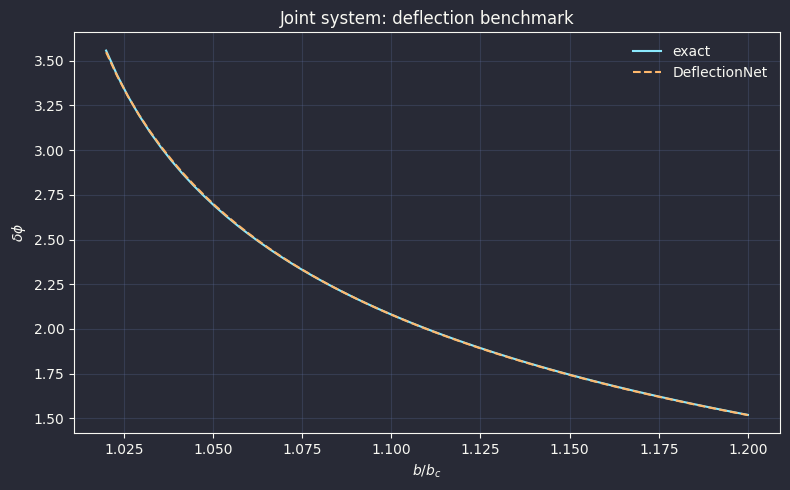

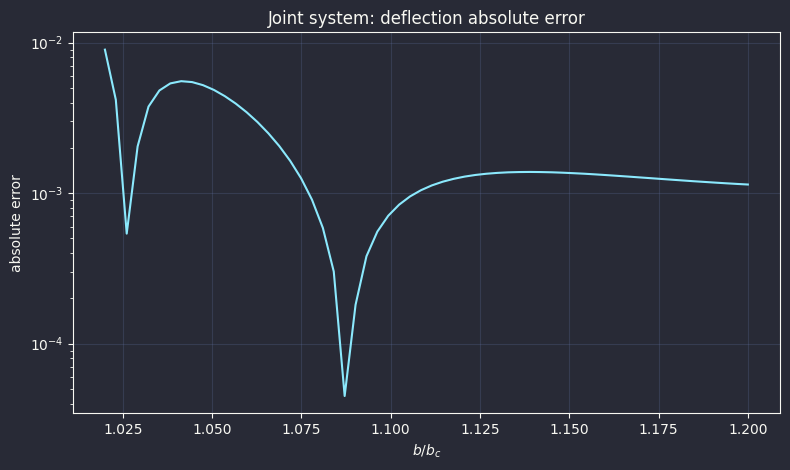

In [26]:
plt.figure(figsize=(8, 5))
plt.plot(joint_df["b_over_bc"], joint_df["dphi_exact"], label="exact")
plt.plot(joint_df["b_over_bc"], joint_df["dphi_pred"], "--", label="DeflectionNet")
plt.xlabel(r"$b/b_c$")
plt.ylabel(r"$\delta\phi$")
plt.title("Joint system: deflection benchmark")
plt.grid(True, alpha=0.25)
plt.legend()
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 4.8))
plt.plot(joint_df["b_over_bc"], joint_df["abs_err"])
plt.yscale("log")
plt.xlabel(r"$b/b_c$")
plt.ylabel("absolute error")
plt.title("Joint system: deflection absolute error")
plt.grid(True, alpha=0.25)
plt.tight_layout()
plt.show()